# 04 — The emergence atlas

Phase 2 deliverable. Reads the metric battery (a CSV per `(size, step, dataset)`) from `data/metric_battery/` and produces the four headline analyses:

1. **Emergence curve** — fraction of parallel-safe tokens vs training step, by size.
2. **Signature accuracy** — how well a probe trained on the other four metrics predicts parallel-safety, vs step.
3. **Token-type breakdown** — parallel-safety stratified by token category.
4. **Domain shift** — how parallel-safety differs across WikiText, MBPP, GSM8K.

Prerequisites: run the metric battery first with `python src/scripts/run_metric_battery.py --sweep`. The notebook degrades gracefully if the cache is partially populated, but every plot needs at least a few cells to be meaningful.

In [1]:
# --- Setup ------------------------------------------------------------------
from __future__ import annotations

import csv
import json
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from hybrid_arch.viz import STYLE

ROOT = Path('..').resolve()
BATTERY = ROOT / 'data' / 'metric_battery'
FIG_DIR = ROOT / 'docs' / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

METRICS = [
    'next_token_entropy', 'top1_probability',
    'attention_entropy', 'attention_top1', 'attention_top3', 'attention_top5',
    'parallel_agreement_rate',
]
PARALLEL_SAFE_THRESHOLD = 0.9  # parallel-safe if agreement rate >= this
PHASE_2_SIZES = ['70m', '160m', '410m']
PHASE_2_DATASETS = ['wikitext', 'mbpp', 'gsm8k']

In [2]:
# --- Loader -----------------------------------------------------------------
def list_cached_cells(battery_dir: Path = BATTERY) -> list[dict]:
    """Discover every cached metric-battery cell. Each entry has keys
    {size, step, dataset, csv_path, manifest}."""
    cells = []
    if not battery_dir.exists():
        return cells
    for manifest_path in battery_dir.rglob('manifest.json'):
        manifest = json.loads(manifest_path.read_text())
        cells.append({
            'size': manifest['size'],
            'step': int(manifest['step']),
            'dataset': manifest['dataset'],
            'csv_path': manifest_path.parent / manifest['csv'],
            'manifest': manifest,
        })
    return cells


def load_cell(csv_path: Path) -> dict[str, np.ndarray]:
    """Load one metric battery CSV into {metric: 1D array}."""
    cols: dict[str, list] = defaultdict(list)
    with csv_path.open() as f:
        reader = csv.DictReader(f)
        for row in reader:
            cols['position'].append(int(row['position']))
            cols['token_id'].append(int(row['token_id']))
            cols['token_str'].append(row['token_str'])
            for m in METRICS:
                cols[m].append(float('nan') if row[m] == 'nan' else float(row[m]))
    out: dict[str, np.ndarray] = {}
    out['position'] = np.array(cols['position'], dtype=np.int64)
    out['token_id'] = np.array(cols['token_id'], dtype=np.int64)
    out['token_str'] = np.array(cols['token_str'], dtype=object)
    for m in METRICS:
        out[m] = np.array(cols[m], dtype=np.float64)
    return out


cells = list_cached_cells()
print(f'Found {len(cells)} cached cells.')
for c in cells[:5]:
    print(f"  {c['size']:>5s} step{c['step']:<6d} {c['dataset']}")
if len(cells) > 5:
    print(f"  ... and {len(cells) - 5} more")

Found 1 cached cells.
   160m step143000 wikitext


## Plot 1 — Emergence curve

For each `(size, step)`, compute the fraction of tokens with `parallel_agreement_rate ≥ 0.9`. Plot vs step on a log x-axis, one line per size, averaged across datasets. This is the project's headline image.

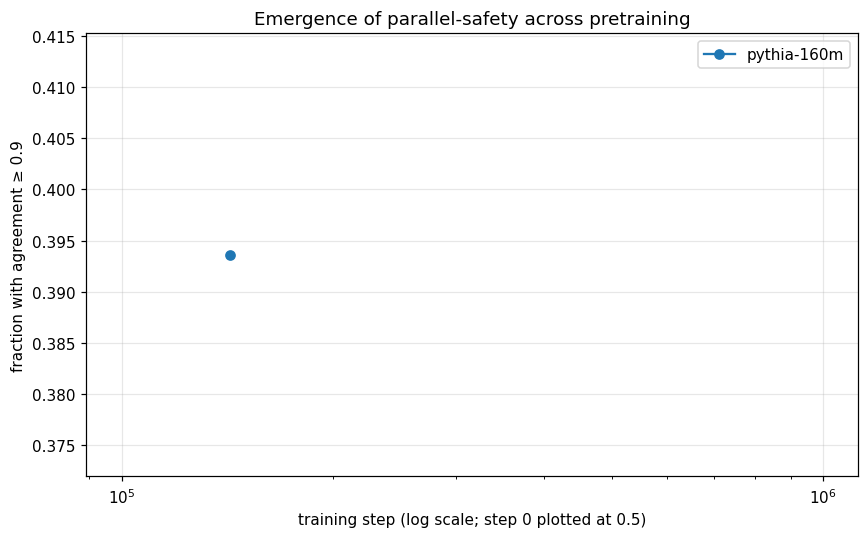

In [3]:
def parallel_safe_fraction(cell_data: dict) -> float:
    rates = cell_data['parallel_agreement_rate']
    valid = ~np.isnan(rates)
    if valid.sum() == 0:
        return float('nan')
    return float((rates[valid] >= PARALLEL_SAFE_THRESHOLD).mean())


by_size_step: dict[tuple[str, int], list[float]] = defaultdict(list)
for c in cells:
    frac = parallel_safe_fraction(load_cell(c['csv_path']))
    if not np.isnan(frac):
        by_size_step[(c['size'], c['step'])].append(frac)

fig, ax = plt.subplots(figsize=(8, 5), dpi=STYLE['dpi'])
for size in PHASE_2_SIZES:
    pts = [(step, np.mean(fracs)) for (s, step), fracs in by_size_step.items() if s == size]
    if not pts:
        continue
    pts.sort()
    xs, ys = zip(*pts)
    # log scale needs positive x; replace step 0 with 0.5 for plotting
    xs_plot = [max(x, 0.5) for x in xs]
    ax.plot(xs_plot, ys, marker='o', label=f'pythia-{size}', linewidth=STYLE['track_linewidth'])

ax.set_xscale('log')
ax.set_xlabel('training step (log scale; step 0 plotted at 0.5)')
ax.set_ylabel(f'fraction with agreement ≥ {PARALLEL_SAFE_THRESHOLD}')
ax.set_title('Emergence of parallel-safety across pretraining')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
if len(by_size_step) >= 6:  # only save when there's enough data to be meaningful
    fig.savefig(FIG_DIR / 'emergence_curve.png', dpi=200)
    print('saved', FIG_DIR / 'emergence_curve.png')
plt.show()

## Plot 2 — Signature accuracy

At each `(size, step)`, train a logistic regression to predict `parallel_agreement_rate ≥ 0.9` from the other six metrics. Plot held-out accuracy vs step. If accuracy stays above ~0.65 across steps, our metrics carry real predictive signal — which is the whole motivation for the Phase 3 probe.

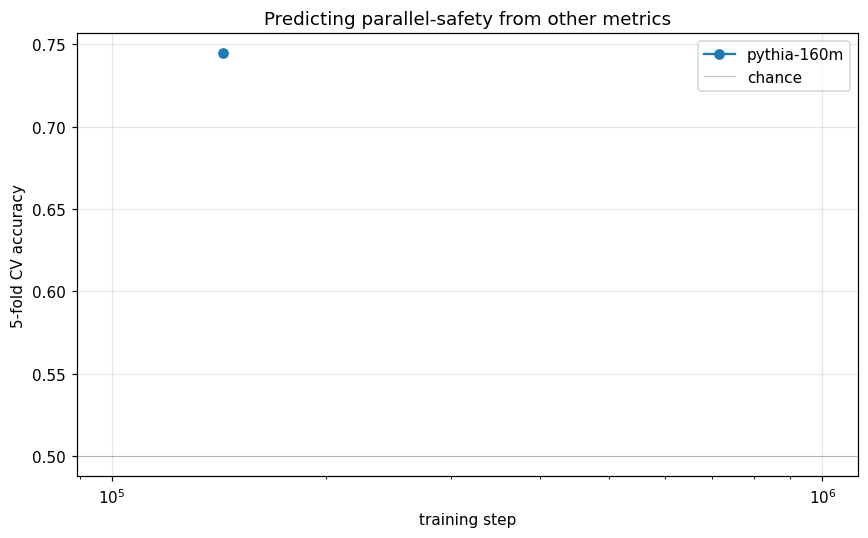

In [4]:
FEATURES = [m for m in METRICS if m != 'parallel_agreement_rate']

def signature_accuracy(cell_data: dict, seed: int = 0) -> float | None:
    """5-fold accuracy of a logistic regression predicting parallel-safety.
    Implemented in numpy + a simple GD-trained linear model to avoid
    pulling in sklearn. Returns None if there's no signal (e.g. all
    same label)."""
    rates = cell_data['parallel_agreement_rate']
    valid = ~np.isnan(rates)
    if valid.sum() < 50:
        return None
    X = np.stack([cell_data[f][valid] for f in FEATURES], axis=1)
    y = (rates[valid] >= PARALLEL_SAFE_THRESHOLD).astype(np.float64)
    if y.std() < 1e-6:
        return None

    rng = np.random.default_rng(seed)
    order = rng.permutation(len(y))
    X, y = X[order], y[order]
    fold_size = len(y) // 5
    accs = []
    for fold in range(5):
        v_lo, v_hi = fold * fold_size, (fold + 1) * fold_size
        X_val, y_val = X[v_lo:v_hi], y[v_lo:v_hi]
        X_tr = np.concatenate([X[:v_lo], X[v_hi:]])
        y_tr = np.concatenate([y[:v_lo], y[v_hi:]])
        # Standardize features.
        mu, sd = X_tr.mean(axis=0), X_tr.std(axis=0) + 1e-6
        X_tr_s, X_val_s = (X_tr - mu) / sd, (X_val - mu) / sd
        # Logistic regression via gradient descent (50 steps).
        w = np.zeros(X_tr_s.shape[1]); b = 0.0; lr = 0.5
        for _ in range(50):
            z = X_tr_s @ w + b
            p = 1.0 / (1.0 + np.exp(-z))
            grad_w = X_tr_s.T @ (p - y_tr) / len(y_tr)
            grad_b = (p - y_tr).mean()
            w -= lr * grad_w; b -= lr * grad_b
        preds = (1.0 / (1.0 + np.exp(-(X_val_s @ w + b))) >= 0.5).astype(np.float64)
        accs.append((preds == y_val).mean())
    return float(np.mean(accs))


sig_by_size_step = defaultdict(list)
for c in cells:
    acc = signature_accuracy(load_cell(c['csv_path']))
    if acc is not None:
        sig_by_size_step[(c['size'], c['step'])].append(acc)

fig, ax = plt.subplots(figsize=(8, 5), dpi=STYLE['dpi'])
for size in PHASE_2_SIZES:
    pts = [(step, np.mean(a)) for (s, step), a in sig_by_size_step.items() if s == size]
    if not pts:
        continue
    pts.sort()
    xs, ys = zip(*pts)
    xs_plot = [max(x, 0.5) for x in xs]
    ax.plot(xs_plot, ys, marker='o', label=f'pythia-{size}', linewidth=STYLE['track_linewidth'])

ax.set_xscale('log')
ax.set_xlabel('training step')
ax.set_ylabel('5-fold CV accuracy')
ax.axhline(0.5, color='grey', linewidth=0.7, alpha=0.5, label='chance')
ax.set_title('Predicting parallel-safety from other metrics')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
if len(sig_by_size_step) >= 6:
    fig.savefig(FIG_DIR / 'signature_accuracy.png', dpi=200)
plt.show()

## Plot 3 — Token-type breakdown

At the final checkpoint, partition tokens by category and show parallel-safety per category. Categories below are heuristic — refine in Phase 3 if useful.

- `space_word`: starts with a space and contains letters (e.g. ` quick`, ` the`)
- `wordpiece`: continuation piece, no leading space, contains letters
- `digit`: contains any digit
- `punct`: only punctuation/whitespace
- `other`: everything else

In [ ]:
def categorize(tok_str: str) -> str:
    if not tok_str:
        return 'other'
    if re.search(r'\d', tok_str):
        return 'digit'
    if re.fullmatch(r'[\s\W_]+', tok_str):
        return 'punct'
    if tok_str.startswith(' '):
        return 'space_word'
    if re.search(r'[A-Za-z]', tok_str):
        return 'wordpiece'
    return 'other'


CATEGORIES = ['space_word', 'wordpiece', 'digit', 'punct', 'other']
FINAL_STEP = 143000
by_cat: dict[str, list[float]] = defaultdict(list)
for c in cells:
    if c['step'] != FINAL_STEP:
        continue
    data = load_cell(c['csv_path'])
    rates = data['parallel_agreement_rate']
    for i, rate in enumerate(rates):
        if np.isnan(rate):
            continue
        by_cat[categorize(data['token_str'][i])].append(float(rate))

fig, ax = plt.subplots(figsize=(8, 5), dpi=STYLE['dpi'])
means = [np.mean(by_cat[c]) if by_cat[c] else 0.0 for c in CATEGORIES]
errs  = [np.std(by_cat[c]) / np.sqrt(max(len(by_cat[c]), 1)) for c in CATEGORIES]
counts = [len(by_cat[c]) for c in CATEGORIES]
ax.bar(CATEGORIES, means, yerr=errs, color=plt.get_cmap(STYLE['sequential_cmap'])(np.linspace(0.2, 0.8, len(CATEGORIES))))
for x, c in enumerate(CATEGORIES):
    ax.text(x, means[x] + errs[x] + 0.01, f'n={counts[x]}', ha='center', fontsize=8)
ax.set_ylabel('mean parallel-agreement rate')
ax.set_title(f'Token-type breakdown at step {FINAL_STEP}')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
# Only save when there's enough data across categories to be meaningful.
if sum(counts) >= 500:
    fig.savefig(FIG_DIR / 'token_type_breakdown.png', dpi=200)
plt.show()

## Plot 4 — Domain shift

At the final checkpoint, mean parallel-safety per dataset and per size. If the patterns from the WikiText-only Phase 1 analysis generalize to code (MBPP) and math (GSM8K), they're likely robust signals; if they collapse, the project thesis needs a domain-specific framing.

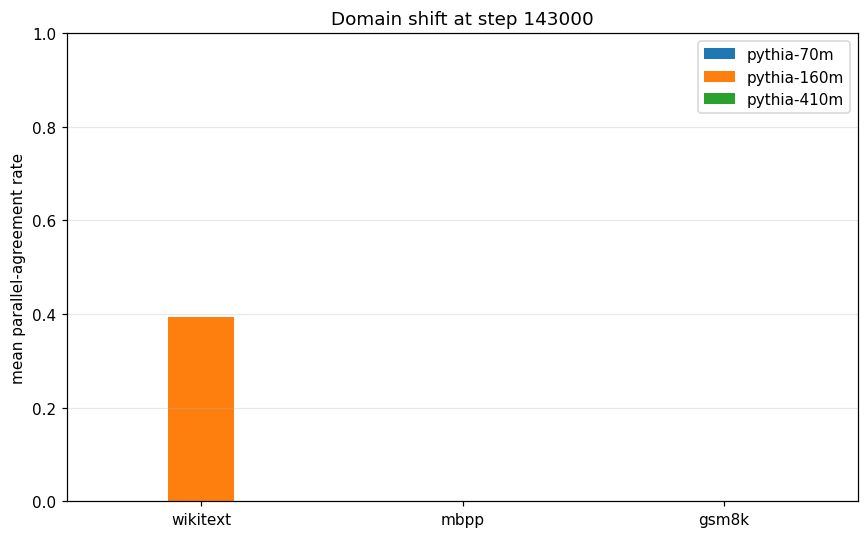

In [6]:
by_size_ds = defaultdict(list)
for c in cells:
    if c['step'] != FINAL_STEP:
        continue
    data = load_cell(c['csv_path'])
    rates = data['parallel_agreement_rate']
    valid = ~np.isnan(rates)
    if valid.sum():
        by_size_ds[(c['size'], c['dataset'])].append(float(rates[valid].mean()))

fig, ax = plt.subplots(figsize=(8, 5), dpi=STYLE['dpi'])
width = 0.25
x = np.arange(len(PHASE_2_DATASETS))
for i, size in enumerate(PHASE_2_SIZES):
    means = [np.mean(by_size_ds.get((size, d), [0.0])) for d in PHASE_2_DATASETS]
    ax.bar(x + (i - 1) * width, means, width, label=f'pythia-{size}')
ax.set_xticks(x)
ax.set_xticklabels(PHASE_2_DATASETS)
ax.set_ylabel('mean parallel-agreement rate')
ax.set_title(f'Domain shift at step {FINAL_STEP}')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
ax.legend()
fig.tight_layout()
if len(by_size_ds) >= 3:
    fig.savefig(FIG_DIR / 'domain_shift.png', dpi=200)
plt.show()

## Coverage report

Print which `(size, step, dataset)` cells are present vs missing in `data/metric_battery/`. Useful for spotting Colab runs that died partway through.

In [7]:
from hybrid_arch import list_checkpoints
present = {(c['size'], c['step'], c['dataset']) for c in cells}
expected = [(s, t, d) for s in PHASE_2_SIZES for t in list_checkpoints() for d in PHASE_2_DATASETS]
missing = [k for k in expected if k not in present]
print(f'present : {len(present)}/{len(expected)}')
print(f'missing : {len(missing)}')
for k in missing[:20]:
    print(f'  {k[0]:>5s}  step{k[1]:<6d}  {k[2]}')
if len(missing) > 20:
    print(f'  ... and {len(missing) - 20} more')

present : 1/108
missing : 107
    70m  step0       wikitext
    70m  step0       mbpp
    70m  step0       gsm8k
    70m  step1       wikitext
    70m  step1       mbpp
    70m  step1       gsm8k
    70m  step8       wikitext
    70m  step8       mbpp
    70m  step8       gsm8k
    70m  step128     wikitext
    70m  step128     mbpp
    70m  step128     gsm8k
    70m  step1000    wikitext
    70m  step1000    mbpp
    70m  step1000    gsm8k
    70m  step4000    wikitext
    70m  step4000    mbpp
    70m  step4000    gsm8k
    70m  step16000   wikitext
    70m  step16000   mbpp
  ... and 87 more
